In [1]:
from utils.experiment_utils import get_all_experiments_info, load_best_model
import torch
import os
import hydra
from omegaconf import DictConfig, OmegaConf

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

import ot

In [2]:
configs = get_all_experiments_info('/orcd/data/omarabu/001/njwfish/CoupledDistributionEmbeddings/outputs/', False)

fm_ab_name = "mvn_coupled_exp_573d309e252656dbd190b72cc1dd62e7"

fm_all_pairs_name = "mvn_coupled_exp_5c54ba6cfe4d9508c62982b071aa1f1a"


In [3]:
cfgs = [c for c in configs if c['name'] in [fm_ab_name, fm_all_pairs_name]]

In [4]:
# shifted dataset

dataset_cfg = cfgs[1]['config']['dataset']
dataset = hydra.utils.instantiate(dataset_cfg)

In [79]:
# 0,5 grid in xy

mu_grid = np.array(np.meshgrid(np.linspace(0,5,20), 
                               np.linspace(0,5,20))).T.reshape(-1,2)

dataset.mu = mu_grid

covs = np.tile(np.eye(2)[np.newaxis, :, :], (mu_grid.shape[0], 1, 1))

dataset.cov = covs

dataset.data = dataset.sample(dataset.mu,
                              dataset.cov, 
                              len(mu_grid),
                              dataset.set_size,
                              (2,))

target_mu = [dataset.mu[i] + dataset.mu[i] @ dataset.cov[i] for i in range(len(dataset.mu))]

In [80]:
def load_model(cfg, path, device):
    enc = hydra.utils.instantiate(cfg['encoder'])
    gen = hydra.utils.instantiate(cfg['generator'])
    state = load_best_model(path)
    enc.load_state_dict(state['encoder_state_dict'])
    gen.load_state_dict(state['generator_state_dict'])
    enc.eval()
    gen.eval()
    enc.to(device)
    gen.to(device)
    return enc, gen

In [81]:
enc_paired, gen_paired = load_model(cfgs[1]['config'], cfgs[1]['dir'], 'cuda')
enc_all, gen_all = load_model(cfgs[0]['config'], cfgs[0]['dir'], 'cuda')

In [82]:
res_d = {
    'mu_x': [],
    'mu_y': [],
    'emd_paired': [],
    'emd_all': []
}

dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

for i, d in enumerate(dataloader):

    x = d['source_samples'].cuda()
    y = d['target_samples'].cuda()

    idx = d['source_idx'].numpy()
    mu = dataset.mu[idx]

    with torch.no_grad():

        # using paired model
        z_src = enc_paired(x)
        z_tgt = enc_paired(y)
        y_hat_paired = gen_paired.sample(source_samples=x.reshape(-1, 2), 
                        source_latent=z_src, target_latent=z_tgt,
                        num_steps=10)
        
        # using all pairs model
        z_src_all = enc_all(x)
        z_tgt_all = enc_all(y)
        y_hat_all = gen_all.sample(source_samples=x.reshape(-1, 2),
                            source_latent=z_src_all, target_latent=z_tgt_all,
                            num_steps=10)

        # compute emd between true and predicted
        x_np = x.cpu().numpy().reshape(-1, 2)
        y_np = y.cpu().numpy().reshape(-1, 2)
        y_hat_paired_np = y_hat_paired.cpu().numpy().reshape(-1, 2)
        y_hat_all_np = y_hat_all.cpu().numpy().reshape(-1, 2)
        M_paired = ot.dist(y_np, y_hat_paired_np)
        M_all = ot.dist(y_np, y_hat_all_np)
        emd_paired = ot.emd2([], [], M_paired) / y_np.shape[0]
        emd_all = ot.emd2([], [], M_all) / y_np.shape[0]
        
        res_d['mu_x'].append(mu[0][0])
        res_d['mu_y'].append(mu[0][1])
        res_d['emd_paired'].append(emd_paired)
        res_d['emd_all'].append(emd_all)


            # # visualize results of both models

            # x = x.cpu().numpy()
            # y = y.cpu().numpy()
            # y_hat_paired = y_hat_paired.cpu().numpy()
            # y_hat_all = y_hat_all.cpu().numpy()
            # fig, axs = plt.subplots(1, 3, figsize=(6,2), dpi=100)

            # # first plot true
            # axs[0].scatter(x[0, :, 0], x[0, :, 1],
            #             color='blue', label='x')
            # axs[0].scatter(y[0, :, 0], y[0, :, 1],
            #             color='green', label='y')
            
            # # next plot paired
            # axs[1].scatter(x[0, :, 0], x[0, :, 1],
            #             color='blue', label='x')
            # axs[1].scatter(y_hat_paired[0, :, 0], y_hat_paired[0, :, 1],
            #             color='red', label='y_hat_paired')
            
            # # next plot all pairs
            # axs[2].scatter(x[0, :, 0], x[0, :, 1],
            #             color='blue', label='x')
            # axs[2].scatter(y_hat_all[0, :, 0], y_hat_all[0, :, 1],
            #             color='orange', label='y_hat_all_pairs')
            
            # axs[0].set_title('True')
            # axs[1].set_title('Paired Model')
            # axs[2].set_title('All Pairs Model')
            # plt.suptitle('shift: %d' %s)
            # plt.tight_layout()
            # plt.show()

In [83]:
res_df = pd.DataFrame(res_d)

/tmp/ipykernel_439347/2715610164.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


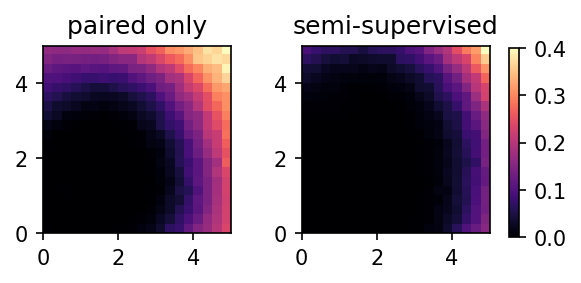

In [84]:
fig, axs = plt.subplots(1, 3, figsize=(4, 2), dpi=150, gridspec_kw={'width_ratios': [1, 1, 0.05]})
tab = pd.pivot_table(res_df, index='mu_x', columns='mu_y', values='emd_paired')
# reorient so 0, 0 is bottom left
tab = tab.iloc[::-1, :]
# sns.heatmap(tab, ax=axs[0], cmap='viridis', square=True)
axs[0].imshow(tab, cmap='magma', aspect='equal', extent=(0,5,0,5), vmin=0, vmax=0.4)

tab = pd.pivot_table(res_df, index='mu_x', columns='mu_y', values='emd_all')
# reorient so 0, 0 is bottom left
tab = tab.iloc[::-1, :]
# sns.heatmap(tab, ax=axs[1], cmap='viridis', square=True)
axs[1].imshow(tab, cmap='magma', aspect='equal', extent=(0,5,0,5), vmin=0, vmax=0.4)

axs[0].set_title('paired only')

axs[1].set_title('semi-supervised')

# colorbar
cbar = fig.colorbar(axs[1].images[0], ax=axs, orientation='vertical', 
                    fraction=0.05, pad=0.1, shrink=0.82)

# remove axs[2]

axs[2].remove()
# 
plt.tight_layout()


In [95]:
pretty_palette = ["#1b718c",
          "#cb4f70",
          "#779e1a",
          "#f49044"]

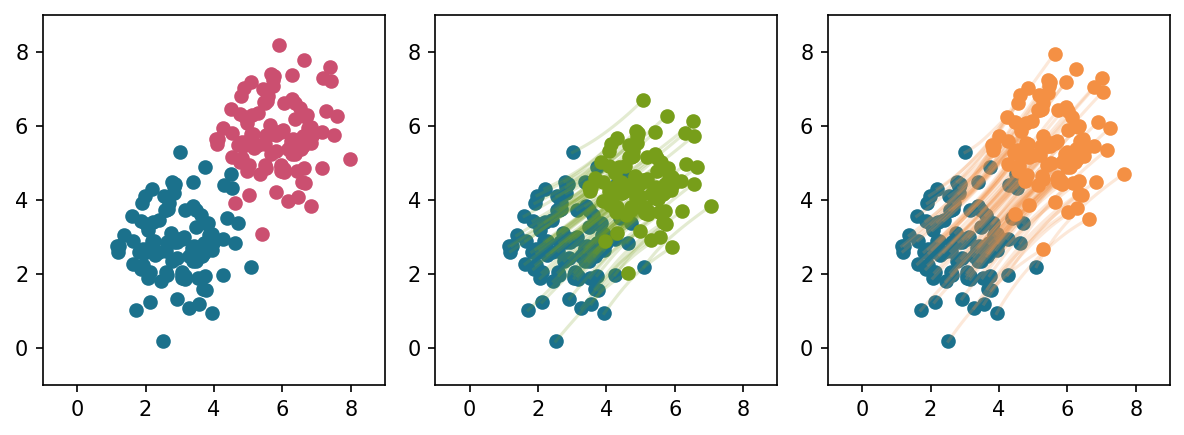

In [ ]:
# next visualize trajectories for a single source mu

moi = np.argmin(np.sum(np.pow(dataset.mu - np.array([3, 3]), 2), axis=1))  # mu of interest index

d = dataloader.dataset[moi]

x = d['source_samples'].cuda().unsqueeze(0)
y = d['target_samples'].cuda().unsqueeze(0)


with torch.no_grad():

    # using paired model
    z_src = enc_paired(x)
    z_tgt = enc_paired(y)
    traj_paired = gen_paired.sample(source_samples=x.reshape(-1, 2), 
                    source_latent=z_src, target_latent=z_tgt,
                    num_steps=100, return_trajectory=True)
    
    # using all pairs model
    z_src_all = enc_all(x)
    z_tgt_all = enc_all(y)
    traj_all = gen_all.sample(source_samples=x.reshape(-1, 2),
                        source_latent=z_src_all, target_latent=z_tgt_all,
                        num_steps=100, return_trajectory=True)
    
# plot trajectories

x = x.cpu().numpy()
y = y.cpu().numpy()
traj_paired = traj_paired.cpu().numpy()
traj_all = traj_all.cpu().numpy()

traj_alpha = 0.2

# group xs and ys for plotting

fig, axs = plt.subplots(1, 3, figsize=(8,3), dpi=150)
# first plot paired

for i in range(3):
    axs[i].scatter(x[0, :, 0], x[0, :, 1],
        color=pretty_palette[0], label='x')
axs[0].scatter(y[0, :, 0], y[0, :, 1],
    color=pretty_palette[1], label='y')
axs[0].plot()

axs[1].plot(traj_paired[:, 0, :, 0], traj_paired[:, 0, :, 1],
        color=pretty_palette[2], alpha=traj_alpha)
axs[1].scatter(traj_paired[-1, 0, :, 0], traj_paired[-1, 0, :, 1],
        color=pretty_palette[2])

axs[2].plot(traj_all[:, 0, :, 0], traj_all[:, 0, :, 1],
        color=pretty_palette[3], alpha=traj_alpha)
axs[2].scatter(traj_all[-1, 0, :, 0], traj_all[-1, 0, :, 1],
        color=pretty_palette[3])

# set all xlim ylim
for ax in axs:
    ax.set_xlim(-1, 9)
    ax.set_ylim(-1, 9)

plt.tight_layout()